<a href="https://colab.research.google.com/github/lmispagel/FoodHub_Case_Study/blob/main/FoodHub_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving foodhub_order.csv to foodhub_order (1).csv


In [ ]:
df = pd.read_csv('foodhub_order.csv')

In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


# **Question One: How many rows and columns are present in the data?**

In [ ]:
df.shape

(1898, 9)

# **Question Two: What are the datatypes of the different columns in the dataset?**

In [ ]:
  df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


# **Question Three:  Are there any missing values in the data? If yes, treat them using an appropriate method.**


In [ ]:
pd.DataFrame({'Count':df.isnull().sum()[df.isnull().sum()>0],'Percentage':(df.isnull().sum()[df.isnull().sum()>0]/df.shape[0])*100})


,Count,Percentage


There are no missing values in the data. This can be seen in the above data.

# **Question Four: Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?**

In [ ]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


1. Minimum = 20.000 minutes
2. Average = 27.372 minutes
3. Maximum = 35.000 minutes



**Question 5: How many orders are not rated?**




In [ ]:
df[df['rating'] == 'Not given'].shape[0]

736

736 orders are not rated

# **Question 6: Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)**

In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
df['order_id'].value_counts()

,count
order_id,
1478056,1
1477147,1
1477685,1
1477070,1
1477334,1
...,...
1478198,1
1477449,1
1476966,1


There are 1898 unique order Id's

In [ ]:
df['customer_id'].value_counts()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


There are 1200 unique customer ID's and 698 duplicated customer ID's.

The restaurant with the highest number of orders was Shake Shack, follow by The Meatball Shop and Blue Ribbon Sushi.


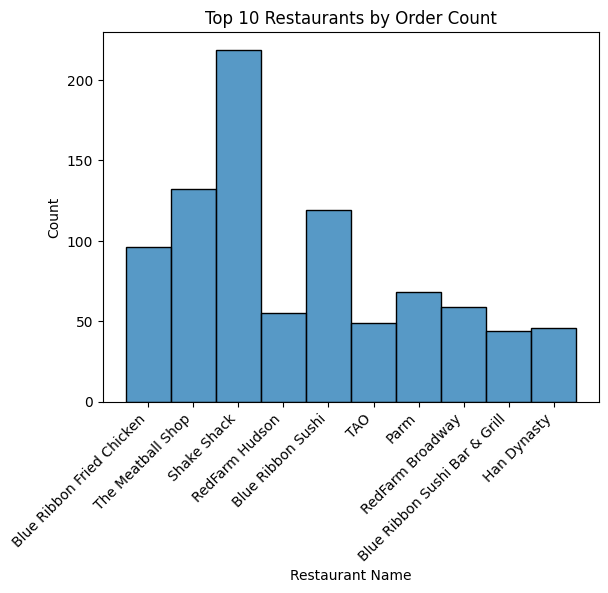

In [ ]:
top_restaurants = df['restaurant_name'].value_counts().head(10).index

sns.histplot(data=df[df['restaurant_name'].isin(top_restaurants)], x='restaurant_name')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Restaurants by Order Count')
plt.xlabel('Restaurant Name');
print('The restaurant with the highest number of orders was Shake Shack, follow by The Meatball Shop and Blue Ribbon Sushi.')

The top 3 cuisines in order are: American, Japanese, Italian.


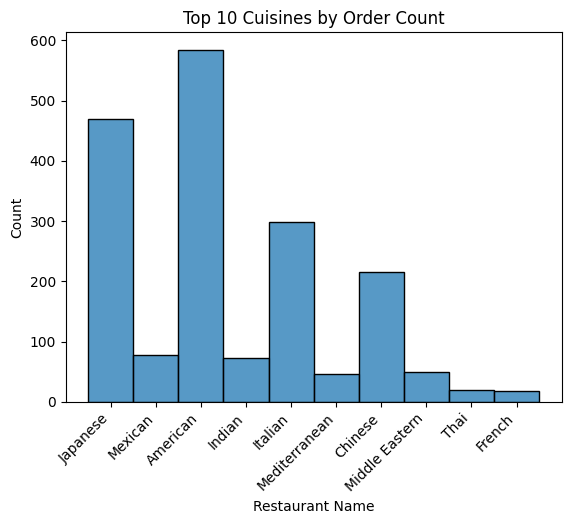

In [ ]:
top_cuisines = df['cuisine_type'].value_counts().head(10).index

sns.histplot(data=df[df['cuisine_type'].isin(top_cuisines)], x='cuisine_type')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Cuisines by Order Count')
plt.xlabel('Restaurant Name');
print('The top 3 cuisines in order are: American, Japanese, Italian.')

Number of Orders on Weekdays vs. Weekends:
day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64
The majority of orders are placed on the weekened.


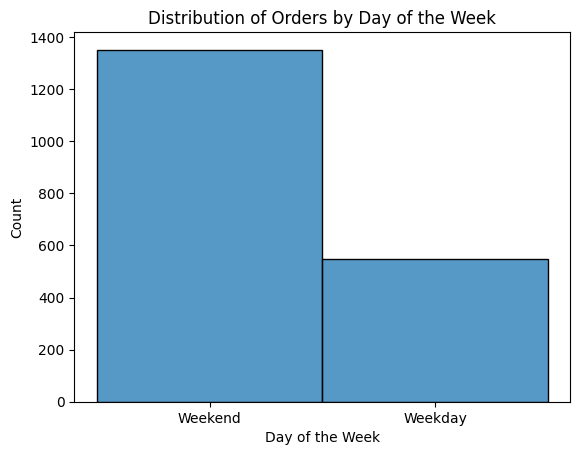

In [ ]:
order_counts = df['day_of_the_week'].value_counts()
print('Number of Orders on Weekdays vs. Weekends:')
print(order_counts)

sns.histplot(data=df, x='day_of_the_week')
plt.title('Distribution of Orders by Day of the Week')
plt.xlabel('Day of the Week');
print('The majority of orders are placed on the weekened.')

A majority of the ratings were between 4.0 and 5.0


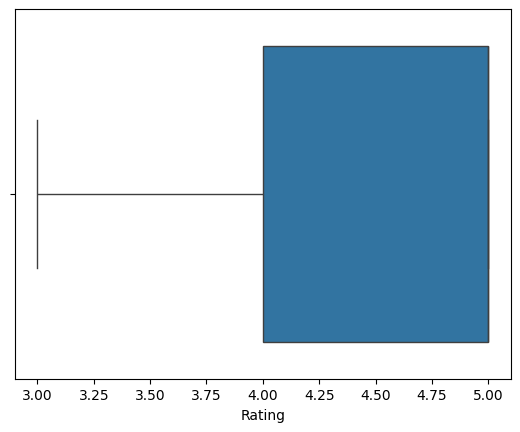

In [ ]:
df_copy = df.copy()
df_copy['rating'] = df_copy['rating'].replace('Not given', np.nan)
df_copy['rating'] = pd.to_numeric(df_copy['rating'], errors='coerce').astype(float)
sns.boxplot(data=df_copy, x='rating')
plt.xlabel('Rating') ;
print('A majority of the ratings were between 4.0 and 5.0')

Most of the food is prepared in the 23-31 minute range.


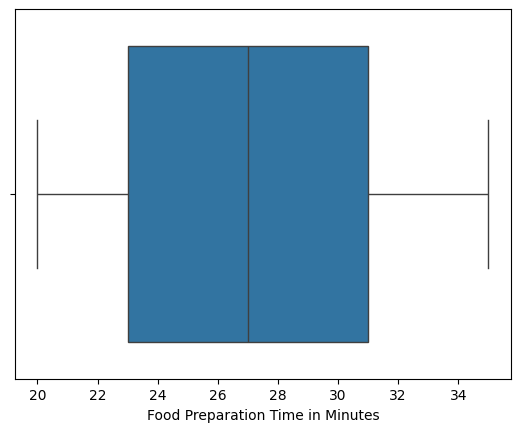

In [ ]:
sns.boxplot(data=df,x='food_preparation_time')
plt.xlabel('Food Preparation Time in Minutes') ;
print('Most of the food is prepared in the 23-31 minute range.')

The majority of the delivery times fall between 20-28 minutes.


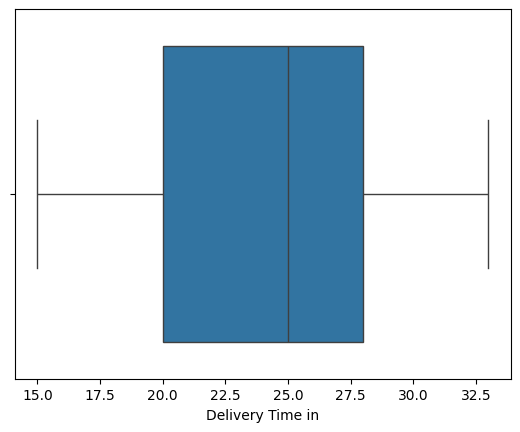

In [ ]:
sns.boxplot(data=df, x='delivery_time')
plt.xlabel('Delivery Time in') ;
print('The majority of the delivery times fall between 20-28 minutes.')

# **Question 7: Which are the top 5 restaurants in terms of the number of orders received?**

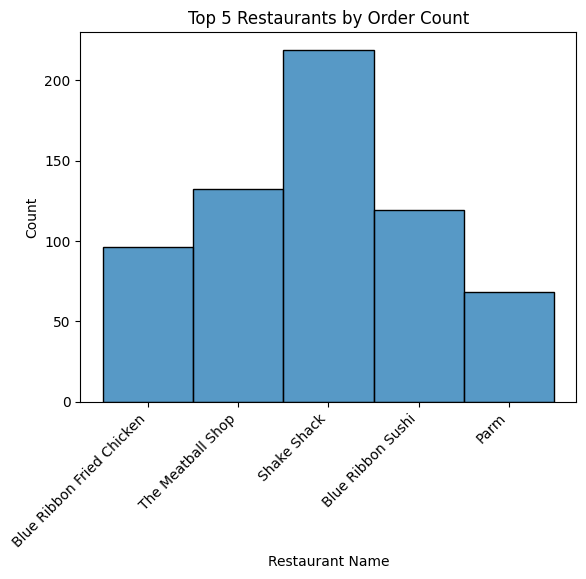

In [ ]:
top_restaurants_5 = df['restaurant_name'].value_counts().head(5).index

sns.histplot(data=df[df['restaurant_name'].isin(top_restaurants_5)], x='restaurant_name')
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 Restaurants by Order Count')
plt.xlabel('Restaurant Name');

# **Question 8: Which is the most popular cuisine on weekends?**

The most popular cuisine of the weekend is American


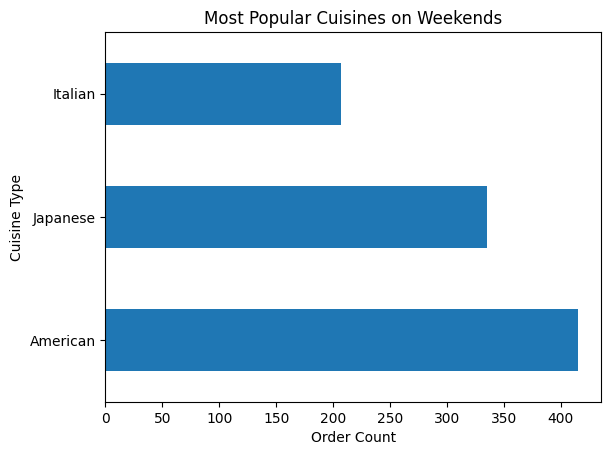

In [ ]:
weekend_orders = df[df['day_of_the_week'] == 'Weekend']
weekend_orders['cuisine_type'].value_counts().head(3).plot(kind='barh')
plt.xlabel('Order Count')
plt.ylabel('Cuisine Type')
plt.title('Most Popular Cuisines on Weekends') ;
print('The most popular cuisine of the weekend is American')

# **Question 9: What percentage of the orders cost more than 20 dollars?**

In [ ]:
orders_more_than_20 = df[df['cost_of_the_order']>20]
percentage_orders_over_20 = (len(orders_more_than_20)/len(df))*100
print(round(percentage_orders_over_20, 2),'% of the orders cost over $20')

29.24 % of the orders cost over $20


# **Question 10: What is the mean order delivery time?**

In [ ]:
print(df['delivery_time'].mean())
print('The average delivery time is 24.16 minutes')

24.161749209694417
The average delivery time is 24.16 minutes


# **Question 11: The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed.**

In [ ]:
df['customer_id'].value_counts().head(5)

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


# **Question 12: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)**

In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


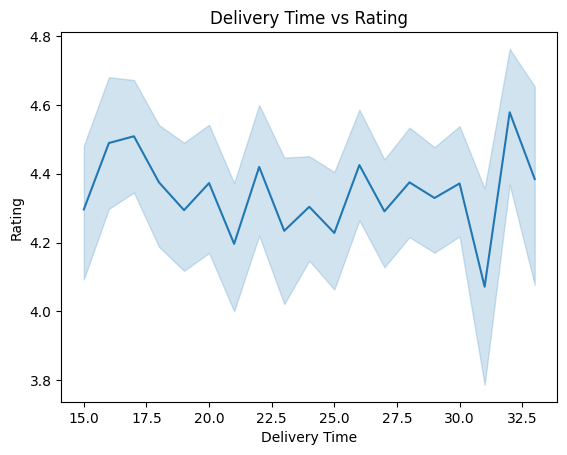

In [ ]:
df_copy = df.copy()
df_copy['rating'] = df_copy['rating'].replace('Not given', np.nan)
df_copy['rating'] = pd.to_numeric(df_copy['rating'], errors='coerce').astype(float)
sns.lineplot(data=df_copy, x='delivery_time', y='rating') ;
plt.xlabel('Delivery Time')
plt.ylabel('Rating')
plt.title('Delivery Time vs Rating');

<Axes: >

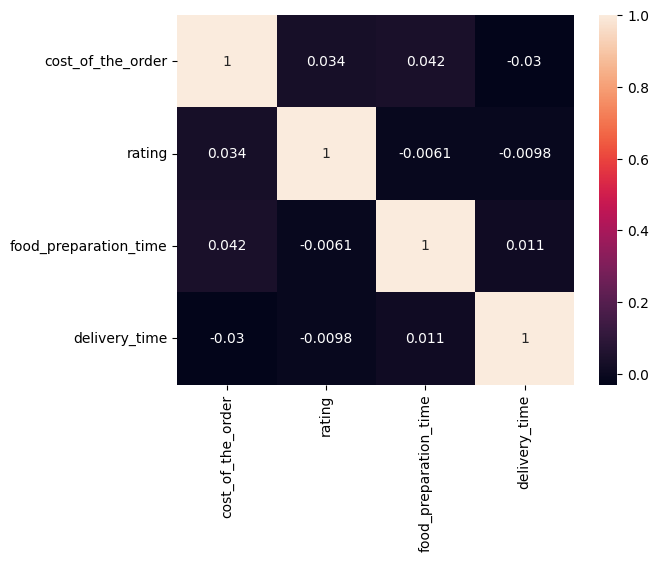

In [ ]:
sns.heatmap(data=df_copy[['cost_of_the_order','rating','food_preparation_time','delivery_time']].corr(),annot=True, cbar=True)

# **Question 13: The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.**

In [ ]:
restaurant_ratings = df_copy.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()
restaurant_ratings.rename(columns={'count': 'rating_count', 'mean': 'average_rating'}, inplace=True)

best_restaurants = restaurant_ratings[(restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)]

print('Restaurants eligible for the promotional offer:')
if not best_restaurants.empty:
    for index, row in best_restaurants.iterrows():
        print(f"- {row['restaurant_name']} (Rating Count: {row['rating_count']}, Average Rating: {row['average_rating']:.2f})")
else:
    print('No restaurants found that meet the criteria.')

Restaurants eligible for the promotional offer:
- Blue Ribbon Fried Chicken (Rating Count: 64, Average Rating: 4.33)
- Blue Ribbon Sushi (Rating Count: 73, Average Rating: 4.22)
- Shake Shack (Rating Count: 133, Average Rating: 4.28)
- The Meatball Shop (Rating Count: 84, Average Rating: 4.51)


# **Question 14: The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.**

In [ ]:
df_company_revenue = df.copy()

def calculate_net_revenue(row):
  cost = row['cost_of_the_order']
  if cost > 20:
    return 0.25 * cost
  elif cost > 5:
    return 0.15 * cost
  else:
    return 0

df_company_revenue['company_revenue'] = df_company_revenue.apply(calculate_net_revenue, axis=1)
net_revenue_of_percents = df_company_revenue['company_revenue'].sum()
print(f"${net_revenue_of_percents:.2f} was the net revenue of the company across all orders")

$6166.30 was the net revenue of the company across all orders


# **Question 15: The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)**

In [ ]:
total_time = df['food_preparation_time'] + df['delivery_time']
orders_over_60_minutes = total_time[total_time > 60].count()
percentage_over_60_minutes = (orders_over_60_minutes / len(df)) * 100
print(f"{percentage_over_60_minutes:.2f}% of orders take more than 60 minutes to deliver.")

10.54% of orders take more than 60 minutes to deliver.


# **Question 16: The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?**

Mean Delivery Time by Weekend or Weekday:
  day_of_the_week  delivery_time
0         Weekday      28.340037
1         Weekend      22.470022


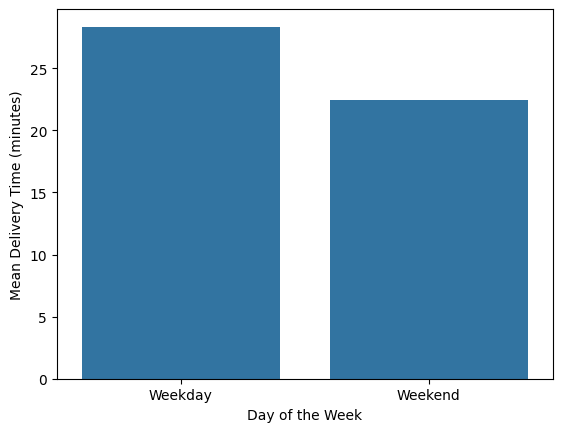

The mean delivery time is higher on weekdays.


In [ ]:
delivery_time_mean = df.groupby('day_of_the_week')['delivery_time'].mean().reset_index()
print('Mean Delivery Time by Weekend or Weekday:')
print(delivery_time_mean)

sns.barplot(data=delivery_time_mean, x='day_of_the_week', y='delivery_time')
plt.xlabel('Day of the Week')
plt.ylabel('Mean Delivery Time (minutes)')
plt.show();
print('The mean delivery time is higher on weekdays.')

# **Question 17: What are your conclusions from the analysis? What recommendations would you like to share to help improve the business?**



*   Operational insights: Average prep time = 27.4, Average delivery time = 24.2, and 10.54% of orders taking over 60 minutes
*   Revenue Insights: With the tiered company charges, there was a total revenue of 37,481.12 dollars.
*   Quality Insights: 736 unrated orders, 38.8%, is not ideal for tracking user experience or creating promotionals.
*   Customer Insights: 1,200 unique customers with 698 repeat customers shows solid buyer retention.
*  Demand Insights: The signicant increase of buyers on the weekend vs. the weeday, the top 5 restaurants, and the the most popular cuisines can all lead into demand forecasts and marketing decisions.
*  Business recommendations: The business should focus on increasing the sales on weekends through promotionals or advertising that focuses meals or deals over 20 dollars. Most of the customers buy food on the weekend, and if there is a special for meals that are over 20 dollars, then the company will make 25% profit from those meals, vs. 15% from meals 5-20 dollars. The demand for orders on the weekends is higher, so this will only compound with the advertising of meals over 20 dollars.



